In [1]:
import sys, os
import re
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

In [2]:
from tqdm.notebook import tqdm

tqdm.pandas()

### Loading package

In [3]:
import sys
from pathlib import Path

here_path = Path().resolve()
repo_path = here_path.parents[1]
sys.path.append(str(repo_path))

In [4]:
from py.utils import verifyDir,verifyFile

In [5]:
from py.config import Config

cfg = Config()

np.random.seed(cfg.RANDOM_STATE)
cfg.DATA_PATH, cfg.MODEL_PATH

('/media/felipe/DATA21/datasets/', '/media/felipe/DATA21/models/')

### Loading data

In [6]:
DATA_PATH=f"{cfg.DATA_PATH}crimebb/"
SQL_PATH = f"{DATA_PATH}/{cfg.YEAR}/sql/"

### Database connection

In [7]:
from py.database import SQLManager

In [8]:
sql_manager = SQLManager()

In [9]:
sql_manager.cmd_create_user()

User 'crimebb' already exists. Skipping creation.



### Listing sql files and paths

In [10]:
dict_dbs = sql_manager.get_db_names(f"{SQL_PATH}/*.sql")

print("DB Name\n", dict_dbs.keys(),"\n")
print("DB Path\n", dict_dbs.values(),"\n")
print("DBs Dict\n", dict_dbs,"\n")

DB Name
 dict_keys(['crimebb_2019_deutschland_im_deep_web', 'crimebb_2019_dread', 'crimebb_2019_envoy_forum', 'crimebb_2019_runion', 'crimebb_2019_the_hub', 'crimebb_2019_torum', 'crimebb_2019_antichat', 'crimebb_2019_garage4hackers', 'crimebb_2019_greysec', 'crimebb_2019_hackforums', 'crimebb_2019_kernelmode', 'crimebb_2019_mpgh', 'crimebb_2019_offensivecommunity', 'crimebb_2019_raidforums', 'crimebb_2019_safeskyhacks', 'crimebb_2019_stresserforums']) 

DB Path
 dict_values(['/media/felipe/DATA21/datasets/crimebb/2019/sql/crimeBB_2019-10-31_Deutschland_im_Deep_Web.sql', '/media/felipe/DATA21/datasets/crimebb/2019/sql/crimeBB_2019-10-31_Dread.sql', '/media/felipe/DATA21/datasets/crimebb/2019/sql/crimeBB_2019-10-31_Envoy_Forum.sql', '/media/felipe/DATA21/datasets/crimebb/2019/sql/crimeBB_2019-10-31_Runion.sql', '/media/felipe/DATA21/datasets/crimebb/2019/sql/crimeBB_2019-10-31_The_Hub.sql', '/media/felipe/DATA21/datasets/crimebb/2019/sql/crimeBB_2019-10-31_Torum.sql', '/media/felipe/DAT

In [11]:
list_dbs = dict_dbs.keys()

### List of all current databases

In [19]:
list_current_dbs = sql_manager.listDBs()
list_current_dbs

Conn closed 1


['2021_antichat',
 'vectordb',
 '2021_deutschland-im-deep-web',
 '2021_dread',
 '2021_envoy-forum',
 '2021_garage4hackers',
 '2021_raidforums',
 '2021_runion',
 '2021_safe-sky-hacks',
 '2021_the-hub',
 '2021_torum']

### removing databases

In [17]:
if cfg.DELETE_DBS:
    sql_manager.deleteDBs(list_dbs)

Conn closed 1
Conn closed 1


### Excetuting and creating all tables for each db

In [20]:
for db_name in tqdm(list_dbs):
    if db_name not in list_current_dbs:
        sql_manager.createDB(db_name)
        print(db_name, ":", dict_dbs[db_name])
        sql_manager.cmd_db_restore(db_name, dict_dbs[db_name])

  0%|          | 0/16 [00:00<?, ?it/s]

Creating crimebb_2019_deutschland_im_deep_web . . .
Conn closed 1
crimebb_2019_deutschland_im_deep_web : /media/felipe/DATA21/datasets/crimebb/2019/sql/crimeBB_2019-10-31_Deutschland_im_Deep_Web.sql
Backuping ... crimebb_2019_deutschland_im_deep_web
db: crimebb_2019_deutschland_im_deep_web size: 18 MB
RESTORED DB crimebb_2019_deutschland_im_deep_web FINISHED. Size: 18 MB

Creating crimebb_2019_dread . . .
Conn closed 1
crimebb_2019_dread : /media/felipe/DATA21/datasets/crimebb/2019/sql/crimeBB_2019-10-31_Dread.sql
Backuping ... crimebb_2019_dread
db: crimebb_2019_dread size: 148 MB
RESTORED DB crimebb_2019_dread FINISHED. Size: 148 MB

Creating crimebb_2019_envoy_forum . . .
Conn closed 1
crimebb_2019_envoy_forum : /media/felipe/DATA21/datasets/crimebb/2019/sql/crimeBB_2019-10-31_Envoy_Forum.sql
Backuping ... crimebb_2019_envoy_forum
db: crimebb_2019_envoy_forum size: 11 MB
RESTORED DB crimebb_2019_envoy_forum FINISHED. Size: 11 MB

Creating crimebb_2019_runion . . .
Conn closed 1
crim

### Tables and Sizes

In [21]:
db_dict = sql_manager.getDBsSize(list_dbs)
db_dict

db: crimebb_2019_deutschland_im_deep_web size: 18 MB
db: crimebb_2019_dread size: 148 MB
db: crimebb_2019_envoy_forum size: 11 MB
db: crimebb_2019_runion size: 219 MB
db: crimebb_2019_the_hub size: 72 MB
db: crimebb_2019_torum size: 27 MB
db: crimebb_2019_antichat size: 1283 MB
db: crimebb_2019_garage4hackers size: 15 MB
db: crimebb_2019_greysec size: 17 MB
db: crimebb_2019_hackforums size: 17 GB
db: crimebb_2019_kernelmode size: 29 MB
db: crimebb_2019_mpgh size: 3908 MB
db: crimebb_2019_offensivecommunity size: 594 MB
db: crimebb_2019_raidforums size: 103 MB
db: crimebb_2019_safeskyhacks size: 62 MB
db: crimebb_2019_stresserforums size: 12 MB


{'db_name': ['crimebb_2019_deutschland_im_deep_web',
  'crimebb_2019_dread',
  'crimebb_2019_envoy_forum',
  'crimebb_2019_runion',
  'crimebb_2019_the_hub',
  'crimebb_2019_torum',
  'crimebb_2019_antichat',
  'crimebb_2019_garage4hackers',
  'crimebb_2019_greysec',
  'crimebb_2019_hackforums',
  'crimebb_2019_kernelmode',
  'crimebb_2019_mpgh',
  'crimebb_2019_offensivecommunity',
  'crimebb_2019_raidforums',
  'crimebb_2019_safeskyhacks',
  'crimebb_2019_stresserforums'],
 'size': ['18 MB',
  '148 MB',
  '11 MB',
  '219 MB',
  '72 MB',
  '27 MB',
  '1283 MB',
  '15 MB',
  '17 MB',
  '17 GB',
  '29 MB',
  '3908 MB',
  '594 MB',
  '103 MB',
  '62 MB',
  '12 MB']}

In [22]:
df = sql_manager.plot_db_sizes(db_dict)
df["log_val_size"] = np.log(df["val_size"])
df["val_size_Mb"] = df["val_size"]/1000.
df

,size,num_size,str_size,val_size,log_val_size,val_size_Mb
db_name,,,,,,
crimebb_2019_hackforums,17 GB,17,GB,17000000,16.648724,17000.0
crimebb_2019_mpgh,3908 MB,3908,MB,3908000,15.178536,3908.0
crimebb_2019_antichat,1283 MB,1283,MB,1283000,14.064712,1283.0
crimebb_2019_offensivecommunity,594 MB,594,MB,594000,13.294635,594.0
crimebb_2019_runion,219 MB,219,MB,219000,12.296827,219.0
crimebb_2019_dread,148 MB,148,MB,148000,11.904968,148.0
crimebb_2019_raidforums,103 MB,103,MB,103000,11.542484,103.0
crimebb_2019_the_hub,72 MB,72,MB,72000,11.184421,72.0
crimebb_2019_safeskyhacks,62 MB,62,MB,62000,11.034890,62.0


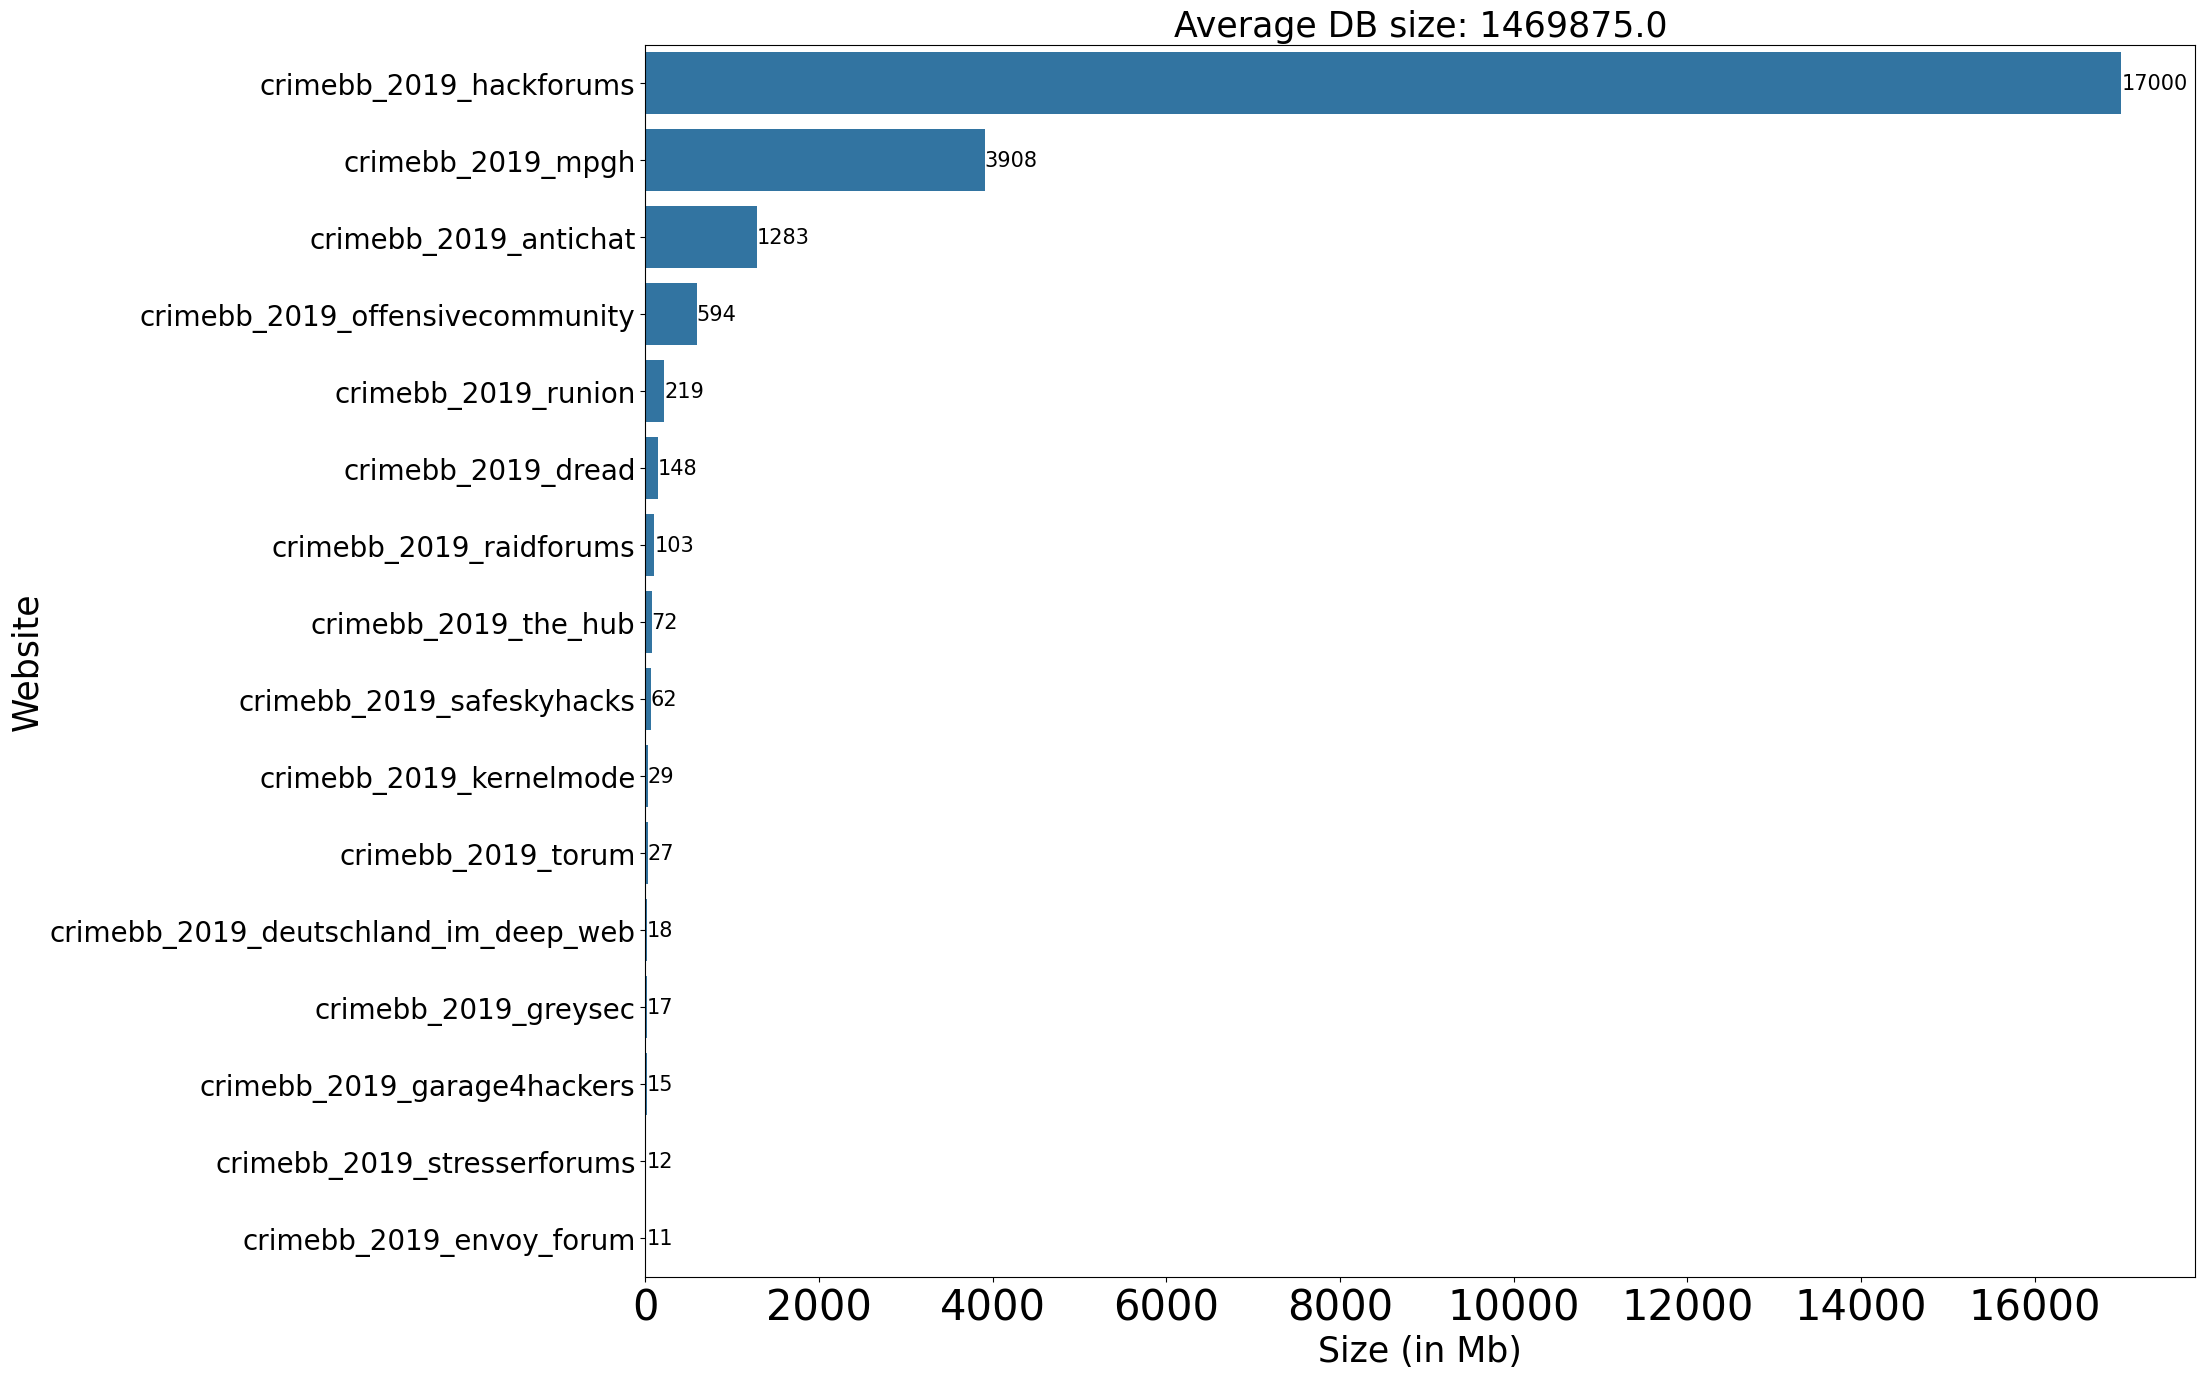

In [23]:
mean_val = round(df["val_size"].mean(), 2)

_, ax = plt.subplots(figsize=(20,16), nrows=1, ncols=1, sharex=False, sharey=False)

df_ = df.reset_index()

sns_fig = sns.barplot(
            data=df_,
            x=df_.columns[6],
            y=df_.columns[0],
            orient="h",
            ax=ax,
            #order=df.sort_values(df.columns[1], ascending=False)[df.columns[0]].loc[:10]
           )

sns_fig.set_title(f"Average DB size: {mean_val}", fontsize=25)
sns_fig.set_ylabel(f"Website", fontsize=25)
sns_fig.set_xlabel('Size (in Mb)', fontsize=25)

# rotate the axis ticklabels
_ = sns_fig.tick_params(axis='x', rotation=0, labelsize=30)

# rotate the axis ticklabels
_ = sns_fig.tick_params(axis='y', labelsize=20)

# add annotation
_ = sns_fig.bar_label(sns_fig.containers[0], fmt='%0.0f', fontsize=15)

# add a space on y for the annotations
#sns_fig.margins(x=0.1)